In [ ]:
# !pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 25.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import spacy
import pdfplumber
import re


c:\Users\mahmo\anaconda3\envs\GP\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


In [5]:
# Load SpaCy English model
nlp = spacy.load("en_core_web_sm")

In [ ]:
df = pd.read_csv("../dataset/job_description.csv")


In [11]:
pd.set_option('display.width', 1000)        # total width of display
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.max_colwidth', None) # show full column content

In [12]:
# pd.reset_option('display.width')
# pd.reset_option('display.max_columns')
# pd.reset_option('display.max_colwidth')

In [13]:
df.head()

,Job Field,Job Title,Job Description,Key Responsibilities,Required Skills & Qualifications
0,Retail Banking,Bank Teller,Front-line customer service professional responsible for processing daily financial transactions and addressing basic customer inquiries.,"• Process deposits, withdrawals, and loan payments.<br>• Balance a cash drawer daily.<br>• Answer account inquiries and identify referral opportunities.","• High school diploma.<br>• Strong cash handling, accuracy, and customer service skills."
1,Retail Banking,Lead Teller,"A senior teller who processes transactions while also providing oversight, coaching, and vault management support to the teller line.",• Perform all teller duties.<br>• Manage and balance the bank vault.<br>• Coach junior tellers and handle escalated customer issues.,"• 2+ years of teller experience.<br>• Leadership potential, advanced problem-solving, and cash vault management skills."
2,Retail Banking,Personal Banker,A sales and service professional in a branch responsible for opening new accounts and selling bank products like loans and credit cards.,• Open new checking/savings accounts and CDs.<br>• Consult with customers to identify needs.<br>• Process consumer loan and credit card applications.<br>• Meet established sales and referral goals.,"• Bachelor's degree preferred.<br>• Strong sales, communication, and relationship-building skills."
3,Retail Banking,Relationship Banker,"A more advanced Personal Banker role focused on developing deeper, long-term relationships with a portfolio of branch clients.","• Proactively manage and grow a portfolio of consumer clients.<br>• Provide holistic financial advice.<br>• Cross-sell a full range of bank products (loans, investments, etc.).","• Bachelor's in Finance/Business.<br>• Proven sales record, financial acumen, and CRM skills."
4,Retail Banking,Small Business Banker,"A specialized banker, often located within a branch, who focuses exclusively on the needs of small business clients.","• Open new business checking accounts.<br>• Originate small business loans (e.g., SBA loans, lines of credit).<br>• Sell treasury/cash management services to small businesses.",• Bachelor's in Business/Finance.<br>• B2B sales skills and a strong understanding of business financial statements.


In [14]:
df.describe()

,Job Field,Job Title,Job Description,Key Responsibilities,Required Skills & Qualifications
count,607,607,607,607,607
unique,91,579,578,578,578
top,Technology Consulting,Grant Writer (Arts),"A specialized writer who researches and writes grant proposals to foundations, corporations, and government agencies (like the NEA) to secure funding for an arts organization.","• Research and identify potential grant funding opportunities.<br>• Write clear, persuasive grant applications and proposals that match the funder's goals.<br>• Gather all supporting documentation (budgets, project plans).<br>• Manage grant deadlines and write final reports on how funds were used.",• Exceptional persuasive writing skills.<br>• Strong research and project management skills.<br>• Ability to write detailed budgets.<br>• Experience in non-profit fundraising.
freq,22,3,3,3,3


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Job Field                         607 non-null    object
 1   Job Title                         607 non-null    object
 2   Job Description                   607 non-null    object
 3   Key Responsibilities              607 non-null    object
 4   Required Skills & Qualifications  607 non-null    object
dtypes: object(5)
memory usage: 23.8+ KB


In [16]:
df.isna().sum()

,0
Job Field,0
Job Title,0
Job Description,0
Key Responsibilities,0
Required Skills & Qualifications,0


In [17]:
cols = ['Job Description', 'Key Responsibilities', 'Required Skills & Qualifications']

merged_df = df.copy()
merged_df['merged_text'] = merged_df[cols].astype(str).agg(' '.join, axis=1)

In [18]:
merged_df.head()

,Job Field,Job Title,Job Description,Key Responsibilities,Required Skills & Qualifications,merged_text
0,Retail Banking,Bank Teller,Front-line customer service professional responsible for processing daily financial transactions and addressing basic customer inquiries.,"• Process deposits, withdrawals, and loan payments.<br>• Balance a cash drawer daily.<br>• Answer account inquiries and identify referral opportunities.","• High school diploma.<br>• Strong cash handling, accuracy, and customer service skills.","Front-line customer service professional responsible for processing daily financial transactions and addressing basic customer inquiries. • Process deposits, withdrawals, and loan payments.<br>• Balance a cash drawer daily.<br>• Answer account inquiries and identify referral opportunities. • High school diploma.<br>• Strong cash handling, accuracy, and customer service skills."
1,Retail Banking,Lead Teller,"A senior teller who processes transactions while also providing oversight, coaching, and vault management support to the teller line.",• Perform all teller duties.<br>• Manage and balance the bank vault.<br>• Coach junior tellers and handle escalated customer issues.,"• 2+ years of teller experience.<br>• Leadership potential, advanced problem-solving, and cash vault management skills.","A senior teller who processes transactions while also providing oversight, coaching, and vault management support to the teller line. • Perform all teller duties.<br>• Manage and balance the bank vault.<br>• Coach junior tellers and handle escalated customer issues. • 2+ years of teller experience.<br>• Leadership potential, advanced problem-solving, and cash vault management skills."
2,Retail Banking,Personal Banker,A sales and service professional in a branch responsible for opening new accounts and selling bank products like loans and credit cards.,• Open new checking/savings accounts and CDs.<br>• Consult with customers to identify needs.<br>• Process consumer loan and credit card applications.<br>• Meet established sales and referral goals.,"• Bachelor's degree preferred.<br>• Strong sales, communication, and relationship-building skills.","A sales and service professional in a branch responsible for opening new accounts and selling bank products like loans and credit cards. • Open new checking/savings accounts and CDs.<br>• Consult with customers to identify needs.<br>• Process consumer loan and credit card applications.<br>• Meet established sales and referral goals. • Bachelor's degree preferred.<br>• Strong sales, communication, and relationship-building skills."
3,Retail Banking,Relationship Banker,"A more advanced Personal Banker role focused on developing deeper, long-term relationships with a portfolio of branch clients.","• Proactively manage and grow a portfolio of consumer clients.<br>• Provide holistic financial advice.<br>• Cross-sell a full range of bank products (loans, investments, etc.).","• Bachelor's in Finance/Business.<br>• Proven sales record, financial acumen, and CRM skills.","A more advanced Personal Banker role focused on developing deeper, long-term relationships with a portfolio of branch clients. • Proactively manage and grow a portfolio of consumer clients.<br>• Provide holistic financial advice.<br>• Cross-sell a full range of bank products (loans, investments, etc.). • Bachelor's in Finance/Business.<br>• Proven sales record, financial acumen, and CRM skills."
4,Retail Banking,Small Business Banker,"A specialized banker, often located within a branch, who focuses exclusively on the needs of small business clients.","• Open new business checking accounts.<br>• Originate small business loans (e.g., SBA loans, lines of credit).<br>• Sell treasury/cash management services to small businesses.",• Bachelor's in Business/Finance.<br>• B2B sales skills and a strong understanding of business financial statements.,"A specialized banker, often located within a branch, who focuses exclusively on the needs of 

In [19]:
clean_df = merged_df.copy()

clean_df['clean_text'] = (
    merged_df['merged_text']
        .str.replace(r'<br\s*/?>', ' ', regex=True)
        .str.replace(r'[•()]', '', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.replace(r'[^\w\s]', '', regex = True)
        .str.strip()
)

In [20]:
clean_df.head(1)

,Job Field,Job Title,Job Description,Key Responsibilities,Required Skills & Qualifications,merged_text,clean_text
0,Retail Banking,Bank Teller,Front-line customer service professional responsible for processing daily financial transactions and addressing basic customer inquiries.,"• Process deposits, withdrawals, and loan payments.<br>• Balance a cash drawer daily.<br>• Answer account inquiries and identify referral opportunities.","• High school diploma.<br>• Strong cash handling, accuracy, and customer service skills.","Front-line customer service professional responsible for processing daily financial transactions and addressing basic customer inquiries. • Process deposits, withdrawals, and loan payments.<br>• Balance a cash drawer daily.<br>• Answer account inquiries and identify referral opportunities. • High school diploma.<br>• Strong cash handling, accuracy, and customer service skills.",Frontline customer service professional responsible for processing daily financial transactions and addressing basic customer inquiries Process deposits withdrawals and loan payments Balance a cash drawer daily Answer account inquiries and identify referral opportunities High school diploma Strong cash handling accuracy and customer service skills


In [21]:
data = clean_df.drop(columns=['Job Description', 'Key Responsibilities', 'Required Skills & Qualifications', 'merged_text'])

In [22]:
def lemmatize_text(text):
    doc = nlp(text)
    lemmatized = ' '.join([token.lemma_ for token in doc if not token.is_stop])
    return lemmatized

In [23]:
data['clean_text'] = data['clean_text'].apply(lemmatize_text)

In [24]:
data.head(1)

,Job Field,Job Title,clean_text
0,Retail Banking,Bank Teller,frontline customer service professional responsible process daily financial transaction address basic customer inquiry process deposit withdrawal loan payment balance cash drawer daily Answer account inquiry identify referral opportunity high school diploma strong cash handling accuracy customer service skill


# Show data


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

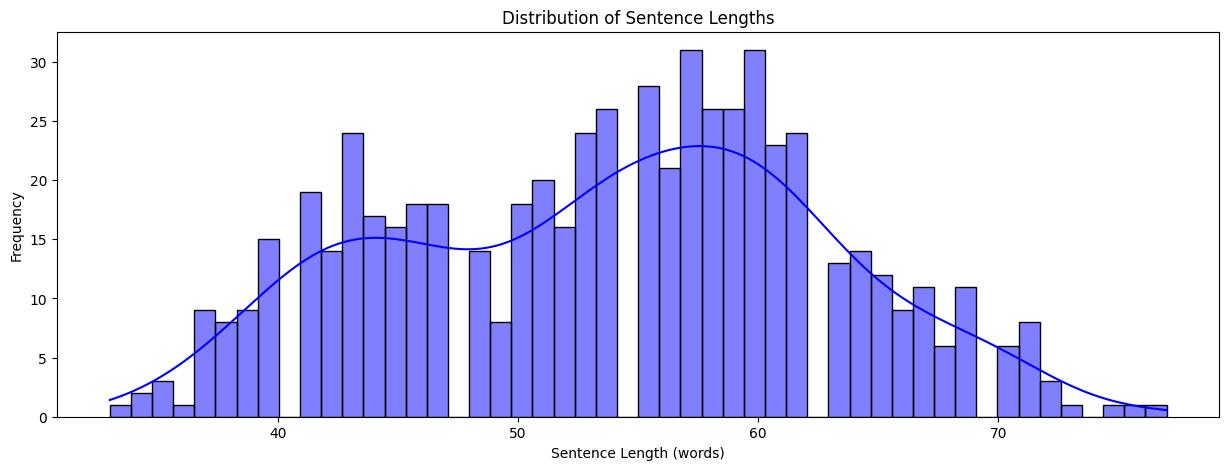

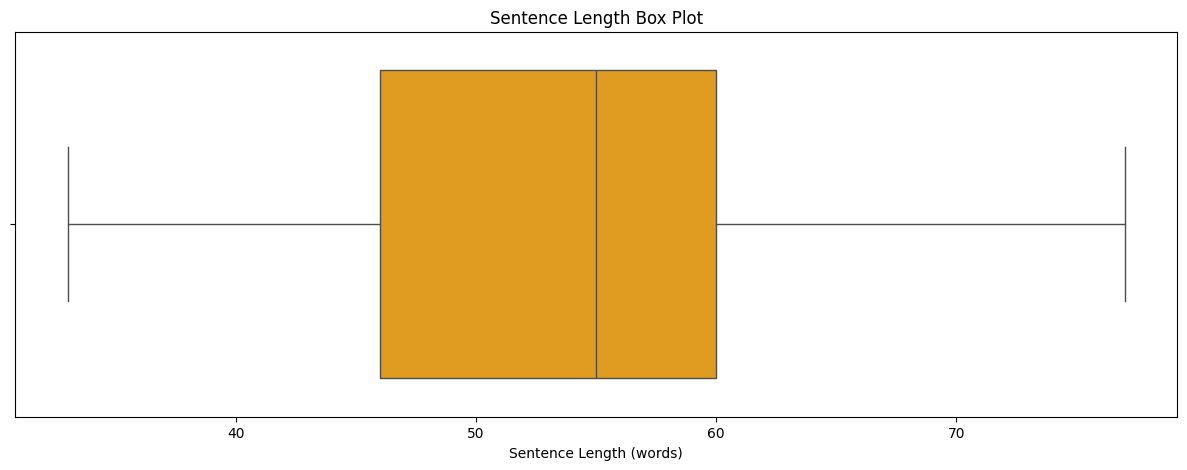

In [26]:
data['sentence_length'] = data['clean_text'].apply(lambda x: len(str(x).split()))  # Word count

#Plot histogram
plt.figure(figsize=(15, 5))
sns.histplot(data['sentence_length'], bins=50, kde=True, color='blue')
plt.xlabel("Sentence Length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of Sentence Lengths")
plt.show()

# # Plot box plot
plt.figure(figsize=(15, 5))
sns.boxplot(x=data['sentence_length'], color='orange')
plt.xlabel("Sentence Length (words)")
plt.title("Sentence Length Box Plot")
plt.show()

# extract cv data

In [27]:
def clean_lemmatize(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Replace HTML breaks and newlines with space
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'\n', ' ', text)

    # 3. Remove emails
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', '', text)

    # 4. Remove phone numbers (digits, spaces, +, -, (), 7+ digits)
    text = re.sub(r'\+?\d[\d\s\-\(\)]{6,}\d', '', text)

    # 5. Remove any remaining non-alphanumeric characters
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # 6. Replace multiple spaces with one
    text = re.sub(r'\s+', ' ', text)

    # 7. Strip leading/trailing spaces
    text = text.strip()

    # 8. Lemmatization with SpaCy
    doc = nlp(text)
    lemmatized_text = ' '.join([token.lemma_ for token in doc if not token.is_stop])

    return lemmatized_text

In [120]:
pdf_file = "Mahmoud Mohamed.pdf"
# pdf_file = "shahd.pdf"

all_text = []

with pdfplumber.open(pdf_file) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            all_text.append(text)

# Join all pages
full_text = "\n".join(all_text)

In [121]:
full_text

'Mahmoud Mohamed\nJunior Software Engineer\n+201156045719 | mahmoud2m2ali@gmail.com | LinkedIn.com/in/Mahmoud | GitHub.com/Mahmoud\nCairo, Egypt\nPROFESSIONAL SUMMARY\nMotivated Software Engineer with a solid background in coding and AI. Dedicated to empowering students to explore\nprogramming through fun, interactive learning experiences.\nEDUCATION\nAin Shams University | 2021 – 2025 Abasia, Cairo\nBachelor’s degree in computer and information science\nEXPERIENCE\nInformation Technology Institute (ITI) | July 2025\nFront-End Trainee\n• Trained on modern client-side technologies: ES.Next, HTML5, Bootstrap, React.js.\n• Built responsive and interactive UI components applying industry-standard best practices.\n• Strengthened front-end development skills through hands-on projects.\nDigital Egypt Pioneers Initiative | April 2024 - October 2024\nSoftware Engineer Trainee (Full-Stack)\n• Developed and deployed web applications using the MERN stack, focusing on providing impactful business\n

In [122]:
full_text = clean_lemmatize(full_text)
full_text

'mahmoud mohamed junior software engineer linkedincominmahmoud githubcommahmoud cairo egypt professional summary motivated software engineer solid background cod ai dedicate empower student explore programming fun interactive learning experience education ain sham university 2021 2025 abasia cairo bachelor degree computer information science experience information technology institute iti july 2025 frontend trainee train modern clientside technology esnext html5 bootstrap reactjs build responsive interactive ui component apply industrystandard good practice strengthen frontend development skill handson project digital egypt pioneer initiative april 2024 october 2024 software engineer trainee fullstack develop deploy web application mern stack focus provide impactful business solution implement secure jwt authentication restful api integration collaborate developer implement scalable solution project search engine nlp technique graduation project grade 2025 tech stack python panda sente

# TF-IDF


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = data['clean_text'].tolist() + [full_text]

In [32]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(corpus)

# tfidf_matrix shape = (num_docs + 1, num_features)
print(tfidf_matrix.shape)

(608, 4975)


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity
similarity_scores = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1])
similarity_scores = similarity_scores.flatten()

# Add to dataframe
data['similarity_with_cv'] = similarity_scores
data.head()

,Job Field,Job Title,clean_text,sentence_length,similarity_with_cv
0,Retail Banking,Bank Teller,frontline customer service professional responsible process daily financial transaction address basic customer inquiry process deposit withdrawal loan payment balance cash drawer daily Answer account inquiry identify referral opportunity high school diploma strong cash handling accuracy customer service skill,38,0.025032
1,Retail Banking,Lead Teller,senior teller process transaction provide oversight coaching vault management support teller line perform teller duty manage balance bank vault Coach junior teller handle escalate customer issue 2 year teller experience Leadership potential advanced problemsolve cash vault management skill,38,0.017760
2,Retail Banking,Personal Banker,sale service professional branch responsible open new account sell bank product like loan credit card open new checkingsaving account cd Consult customer identify need process consumer loan credit card application Meet establish sale referral goal bachelor degree preferred strong sale communication relationshipbuilding skill,43,0.018991
3,Retail Banking,Relationship Banker,advanced Personal Banker role focus develop deep longterm relationship portfolio branch client proactively manage grow portfolio consumer client provide holistic financial advice Crosssell range bank product loan investment etc bachelor FinanceBusiness Proven sale record financial acuman CRM skill,38,0.022428
4,Retail Banking,Small Business Banker,specialized banker locate branch focus exclusively need small business client open new business checking account originate small business loan eg SBA loan line credit sell treasurycash management service small business bachelor BusinessFinance B2B sale skill strong understanding business financial statement,40,0.017575


In [34]:
top_matches = data.sort_values(by='similarity_with_cv', ascending=False)
print(top_matches.head(10))

                 Job Field                            Job Title                                                                                                                                                                                                                                                                                                                                                                                                                                                            clean_text  sentence_length  similarity_with_cv
140               Software                  Full-Stack Engineer                                                                                                                                                                         engineer comfortable work frontend clientside backend serverside part application design build complete web application end end manage database server api clientside UI Work entire software stack solve problem bs 

# Nural Network


In [ ]:
!pip install tensorflow

^C


   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/331.9 MB 335.2 kB/s eta 0:16:29
   ---------------------------------------- 0.5/331.9 MB 335.2 kB/s eta 0:16:29
   ---------------------------------------- 0.5/331.9 MB 335.2 kB/s eta 0:16:29
   ---------------------------------------- 0.5/331.9 MB 335.2 kB/s eta 0:16:29
   ---------------------------------------- 0.8/331.9 MB 345.8 kB/s eta 0:15:58
   ---------------------------------------- 0.8/331.9 MB 345.8 kB/s eta 0:15:58
   ---------------------------------------- 0.8/331.9 MB 345.8 kB/s eta 0:15:58
   -----------

In [35]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [36]:
data.head()

,Job Field,Job Title,clean_text,sentence_length,similarity_with_cv
0,Retail Banking,Bank Teller,frontline customer service professional responsible process daily financial transaction address basic customer inquiry process deposit withdrawal loan payment balance cash drawer daily Answer account inquiry identify referral opportunity high school diploma strong cash handling accuracy customer service skill,38,0.025032
1,Retail Banking,Lead Teller,senior teller process transaction provide oversight coaching vault management support teller line perform teller duty manage balance bank vault Coach junior teller handle escalate customer issue 2 year teller experience Leadership potential advanced problemsolve cash vault management skill,38,0.017760
2,Retail Banking,Personal Banker,sale service professional branch responsible open new account sell bank product like loan credit card open new checkingsaving account cd Consult customer identify need process consumer loan credit card application Meet establish sale referral goal bachelor degree preferred strong sale communication relationshipbuilding skill,43,0.018991
3,Retail Banking,Relationship Banker,advanced Personal Banker role focus develop deep longterm relationship portfolio branch client proactively manage grow portfolio consumer client provide holistic financial advice Crosssell range bank product loan investment etc bachelor FinanceBusiness Proven sale record financial acuman CRM skill,38,0.022428
4,Retail Banking,Small Business Banker,specialized banker locate branch focus exclusively need small business client open new business checking account originate small business loan eg SBA loan line credit sell treasurycash management service small business bachelor BusinessFinance B2B sale skill strong understanding business financial statement,40,0.017575


In [123]:
all_texts = data["clean_text"].tolist()


In [124]:
tokenizer = Tokenizer(oov_token="<UNK>")
tokenizer.fit_on_texts(all_texts)

vocab_size = len(tokenizer.word_index) + 1

encode_data = tokenizer.texts_to_sequences(all_texts)

In [125]:
reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

token_id = 20 # Example token ID
word = reverse_word_index.get(token_id, "UNKNOWN")
print(f"Token {token_id} corresponds to word: {word}")


Token 20 corresponds to word: ensure


In [126]:
# Reverse mapping: {index: word}
reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

# Get the first 200 token-word pairs
tokens_set = {(index, reverse_word_index[index]) for index in list(reverse_word_index.keys())[:200]}

# Print the set
print(tokens_set)


{(119, 'development'), (22, 'strategy'), (161, 'assess'), (23, 'plan'), (91, 'support'), (81, 'health'), (57, 'require'), (56, 'sale'), (4, 'skill'), (88, 'budget'), (160, 'coordinate'), (123, 'oversee'), (25, 'new'), (101, 'lead'), (18, 'degree'), (120, 'prepare'), (181, 'document'), (162, 'need'), (199, 'disease'), (40, 'bank'), (43, 'like'), (111, 'entire'), (145, 'consultant'), (190, 'include'), (156, 'critical'), (167, 'platform'), (142, 'hospital'), (139, 'application'), (10, 'management'), (114, 'public'), (78, 'medical'), (64, 'help'), (61, 'bs'), (187, 'director'), (26, 'analyze'), (191, 'image'), (87, 'implement'), (148, 'security'), (66, 'service'), (195, 'insurance'), (1, '<UNK>'), (21, 'develop'), (140, 'regulation'), (36, 'experience'), (55, 'market'), (73, 'loan'), (54, 'conduct'), (33, 'art'), (41, 'engineering'), (182, 'overall'), (104, 'year'), (121, 'final'), (29, 'analysis'), (154, 'technique'), (27, 'business'), (7, 'patient'), (9, 'knowledge'), (159, 'investment')

In [142]:
# Find the longest sequence length
max_sentence_length = max(len(seq) for seq in encode_data)

# Pad sequences using the dynamically determined maxlen
padded_docs = pad_sequences(encode_data, maxlen=500, padding='post')

print(padded_docs, padded_docs.shape)

[[1566   93   66 ...    0    0    0]
 [  77  728   13 ...    0    0    0]
 [  56   66   60 ...    0    0    0]
 ...
 [ 302 1409   84 ...    0    0    0]
 [  28 1959  212 ...    0    0    0]
 [2697 1124   71 ...    0    0    0]] (607, 500)


In [143]:
print(vocab_size, max_sentence_length)

4925 77


In [144]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=8),
    Flatten()
])

In [145]:
sample_input = tf.convert_to_tensor(padded_docs, dtype=tf.int32)
embedded_output = model(sample_input)
print(embedded_output.shape)
print(embedded_output)

(607, 4000)
tf.Tensor(
[[-0.04989827  0.01469893  0.00999676 ...  0.04878065 -0.0405202
   0.00738009]
 [ 0.01631663  0.00819663  0.01812294 ...  0.04878065 -0.0405202
   0.00738009]
 [ 0.03289486  0.02664342  0.0277924  ...  0.04878065 -0.0405202
   0.00738009]
 ...
 [ 0.01315204  0.03644179 -0.00827607 ...  0.04878065 -0.0405202
   0.00738009]
 [-0.01675558  0.00897694  0.04050162 ...  0.04878065 -0.0405202
   0.00738009]
 [ 0.00669786 -0.01840216 -0.01890985 ...  0.04878065 -0.0405202
   0.00738009]], shape=(607, 4000), dtype=float32)


In [146]:
print(embedded_output[0])


tf.Tensor(
[-0.04989827  0.01469893  0.00999676 ...  0.04878065 -0.0405202
  0.00738009], shape=(4000,), dtype=float32)


In [151]:
query_sequence = tokenizer.texts_to_sequences([full_text])
print(query_sequence)
# Pad the query to match input shape
query_padded = pad_sequences(query_sequence, maxlen=500, padding='post')

# Convert query to embedding
query_embedding = model(tf.constant(query_padded))
# print(query_embedding)
# # Print query shape
print("Query Embedding Shape:", query_embedding.shape)

[[1, 1, 606, 45, 72, 1, 1, 1, 1, 60, 1599, 1, 45, 72, 3410, 112, 1687, 1940, 1, 1, 557, 2553, 569, 4223, 4060, 2674, 36, 336, 1, 1, 1007, 1, 1, 1, 1, 143, 18, 291, 454, 223, 36, 454, 86, 1, 1, 1, 1, 1681, 1, 198, 1364, 2155, 86, 1, 3188, 1, 1, 49, 3181, 4060, 1048, 375, 262, 4229, 491, 234, 1, 1681, 119, 4, 944, 31, 109, 1, 1, 683, 1, 1, 1, 1, 45, 72, 1, 1, 21, 1554, 936, 139, 1, 1201, 37, 52, 1, 27, 412, 87, 406, 1, 1, 1, 1200, 468, 274, 739, 87, 1047, 412, 31, 1563, 533, 1, 154, 2276, 31, 1196, 1, 371, 1201, 456, 4513, 1, 3074, 21, 1563, 533, 1, 1, 247, 2167, 1354, 273, 676, 1, 2, 1164, 1451, 684, 1, 1563, 1, 1, 154, 1, 559, 189, 1, 273, 676, 911, 126, 417, 14, 1, 371, 1201, 755, 1858, 31, 14, 569, 49, 511, 3201, 13, 3974, 1203, 171, 755, 1696, 1203, 1385, 13, 481, 1, 762, 191, 1619, 1, 371, 1201, 755, 1, 2, 1231, 31, 21, 1, 144, 1, 3100, 191, 1, 1, 1687, 154, 87, 1, 1, 1850, 324, 4205, 1, 1, 124, 816, 365, 247, 14, 44, 1, 739, 1, 1, 371, 1201, 3184, 2154, 1, 1, 1, 1, 1, 520, 898, 1,

In [152]:
cos_similarities = cosine_similarity(embedded_output, query_embedding)

cos_similarities = cos_similarities.flatten()

most_similar_index = np.argmax(cos_similarities)

print(f"Most Similar Index: {most_similar_index}")
print(f"Highest Cosine Similarity Score: {cos_similarities[most_similar_index]}")


Most Similar Index: 182
Highest Cosine Similarity Score: 0.18463534116744995


In [153]:
top_n = 10
top_n_indices = np.argsort(cos_similarities)[-top_n:][::-1]  # Sort in descending order

# Print the top 10 most similar embeddings
print("Top 10 most similar indices and their cosine similarity scores:")
for rank, idx in enumerate(top_n_indices, start=1):
    print(f"Rank {rank}: Index {idx}, Similarity: {cos_similarities[idx]:.4f}")

Top 10 most similar indices and their cosine similarity scores:
Rank 1: Index 182, Similarity: 0.1846
Rank 2: Index 422, Similarity: 0.1824
Rank 3: Index 450, Similarity: 0.1824
Rank 4: Index 73, Similarity: 0.1821
Rank 5: Index 12, Similarity: 0.1812
Rank 6: Index 46, Similarity: 0.1811
Rank 7: Index 4, Similarity: 0.1809
Rank 8: Index 163, Similarity: 0.1806
Rank 9: Index 5, Similarity: 0.1804
Rank 10: Index 389, Similarity: 0.1801


In [159]:
all_texts[182]

'engineer focus optimize complex system process eliminate waste process fast safe efficient costeffective Analyze manufacturing service process find bottleneck use statistical analysis modeling improve efficiency design factory floor layout optimal workflow Implement Lean Manufacturing Sigma principle BS Industrial   Systems Engineering ISE'

In [160]:
data['Job Title'][182]

'Industrial Engineer (IE)'

In [161]:
data['clean_text'][182]

'engineer focus optimize complex system process eliminate waste process fast safe efficient costeffective Analyze manufacturing service process find bottleneck use statistical analysis modeling improve efficiency design factory floor layout optimal workflow Implement Lean Manufacturing Sigma principle BS Industrial   Systems Engineering ISE'

In [157]:
word_count = len(full_text.split())
print("Word count:", word_count)

Word count: 474
